## Description
At Santander our mission is to help people and businesses prosper. We are always looking for ways to help our customers understand their financial health and identify which products and services might help them achieve their monetary goals.

Our data science team is continually challenging our machine learning algorithms, working with the global data science community to make sure we can more accurately identify new ways to solve our most common challenge, binary classification problems such as: is a customer satisfied? Will a customer buy this product? Can a customer pay this loan?

In this challenge, we invite Kagglers to help us identify which customers will make a specific transaction in the future, irrespective of the amount of money transacted. The data provided for this competition has the same structure as the real data we have available to solve this problem.

### Dataset Description
You are provided with an anonymized dataset containing numeric feature variables, the binary target column, and a string ID_code column.

The task is to predict the value of target column in the test set.

### Evaluation
Submissions are evaluated on area under the ROC curve between the predicted probability and the observed target.

### Submission File
For each Id in the test set, you must make a binary prediction of the target variable. The file should contain a header and have the following format:

### ID_code,target
test_0,0

test_1,1

test_2,0

etc.

### 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### 2. Importing the data

In [2]:
train_df = pd.read_csv(r'Datasets/santander-customer-transaction-prediction/train.csv')

In [3]:
test_df = pd.read_csv(r'Datasets/santander-customer-transaction-prediction/test.csv')

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [5]:
train_df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [6]:
train_df.tail()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
199995,train_199995,0,11.4880,-0.4956,8.2622,3.5142,10.3404,11.6081,5.6709,15.1516,...,6.1415,13.2305,3.9901,0.9388,18.0249,-1.7939,2.1661,8.5326,16.6660,-17.8661
199996,train_199996,0,4.9149,-2.4484,16.7052,6.6345,8.3096,-10.5628,5.8802,21.5940,...,4.9611,4.6549,0.6998,1.8341,22.2717,1.7337,-2.1651,6.7419,15.9054,0.3388
199997,train_199997,0,11.2232,-5.0518,10.5127,5.6456,9.3410,-5.4086,4.5555,21.5571,...,4.0651,5.4414,3.1032,4.8793,23.5311,-1.5736,1.2832,8.7155,13.8329,4.1995
199998,train_199998,0,9.7148,-8.6098,13.6104,5.7930,12.5173,0.5339,6.0479,17.0152,...,2.6840,8.6587,2.7337,11.1178,20.4158,-0.0786,6.7980,10.0342,15.5289,-13.9001
199999,train_199999,0,10.8762,-5.7105,12.1183,8.0328,11.5577,0.3488,5.2839,15.2058,...,8.9842,1.6893,0.1276,0.3766,15.2101,-2.4907,-2.2342,8.1857,12.1284,0.1385


In [7]:
test_df.head()

,ID_code,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,test_0,11.0656,7.7798,12.9536,9.4292,11.4327,-2.3805,5.8493,18.2675,2.1337,...,-2.1556,11.8495,-1.4300,2.4508,13.7112,2.4669,4.3654,10.7200,15.4722,-8.7197
1,test_1,8.5304,1.2543,11.3047,5.1858,9.1974,-4.0117,6.0196,18.6316,-4.4131,...,10.6165,8.8349,0.9403,10.1282,15.5765,0.4773,-1.4852,9.8714,19.1293,-20.9760
2,test_2,5.4827,-10.3581,10.1407,7.0479,10.2628,9.8052,4.8950,20.2537,1.5233,...,-0.7484,10.9935,1.9803,2.1800,12.9813,2.1281,-7.1086,7.0618,19.8956,-23.1794
3,test_3,8.5374,-1.3222,12.0220,6.5749,8.8458,3.1744,4.9397,20.5660,3.3755,...,9.5702,9.0766,1.6580,3.5813,15.1874,3.1656,3.9567,9.2295,13.0168,-4.2108
4,test_4,11.7058,-0.1327,14.1295,7.7506,9.1035,-8.5848,6.8595,10.6048,2.9890,...,4.2259,9.1723,1.2835,3.3778,19.5542,-0.2860,-5.1612,7.2882,13.9260,-9.1846


In [8]:
train_df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


In [9]:
train_df.columns

Index(['ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4',
       'var_5', 'var_6', 'var_7',
       ...
       'var_190', 'var_191', 'var_192', 'var_193', 'var_194', 'var_195',
       'var_196', 'var_197', 'var_198', 'var_199'],
      dtype='object', length=202)

# Phase 1: Data Understanding & Exploration

## Objective
Before we can effectively visualize and engineer features, we need to understand what we're working with:
- **Data Integrity Check**: Verify the dataset is complete and valid (no missing values, correct shapes)
- **Target Analysis**: Understand class balance (is it 50-50, 90-10, etc.?)
- **Feature Characteristics**: What are the ranges, distributions, and potential outliers?
- **Data Anomalies**: Are there duplicate rows or features with zero variance?

## Why This Matters
✓ Data quality issues can ruin model performance  
✓ Class imbalance affects model training strategy  
✓ Understanding feature ranges helps with normalization decisions  
✓ Identifying constant features prevents model errors

---

## Step-by-Step Breakdown

### 1. Data Integrity Verification
- Load train and test data (already done)
- Check shape: How many rows and columns?
- Check missing values: Are there any NaN values?
- Check data types: What type is each column?

### 2. Target Distribution Analysis
- Count how many rows have target=0 and target=1
- Calculate percentages (e.g., "70% have target=0, 30% have target=1")
- Visualize with a bar chart or pie chart
- **Insight**: If one class dominates (e.g., 95-5), we need special handling in models

### 3. Feature Statistics
- Calculate min, max, mean, std for all 200 features
- Identify outliers (extreme values)
- Look for features with very similar values across all rows

### 4. Anomaly Detection
- Check for duplicated rows (same values, different customers)
- Find zero-variance features (same value for every row - useless for modeling)
- Identify potential data quality issues

In [10]:
# ============================================================================
# PHASE 1, STEP 1: DATA INTEGRITY VERIFICATION
# ============================================================================

print("=" * 70)
print("PHASE 1: DATA UNDERSTANDING & EXPLORATION")
print("=" * 70)

# --- Step 1a: Check Dataset Dimensions ---
print("\n📊 STEP 1a: Dataset Dimensions")
print("-" * 70)
print(f"Training set shape: {train_df.shape}")
print(f"  → {train_df.shape[0]:,} rows (customers) × {train_df.shape[1]} columns")
#          In {train_df.shape[0]:,} the : specifies that we want to format the data before and , is the format specifier

print(f"\nTest set shape: {test_df.shape}")
print(f"  → {test_df.shape[0]:,} rows (customers to predict) × {test_df.shape[1]} columns")

# --- Step 1b: Check Data Types ---
print("\n📋 STEP 1b: Data Types")
print("-" * 70)
print(f"Unique data types in training set:\n{train_df.dtypes.value_counts()}\n")
print("Interpretation:")

# --- Step 1c: Check Missing Values ---
print("\n🔍 STEP 1c: Missing Values (Data Quality)")
print("-" * 70)
missing_summary = train_df.isnull().sum()
cols_with_missing = missing_summary[missing_summary > 0]

if len(cols_with_missing) == 0:
    print("✅ EXCELLENT! No missing values found in training set")
    print("   → All 200 columns have complete data")
else:
    print(f"⚠️ WARNING! {len(cols_with_missing)} columns have missing values:")
    print(cols_with_missing)

print(f"\n✅ Test set also complete: {test_df.isnull().sum().sum()} missing values")

# --- Step 1d: Preview Column Names ---
print("\n📝 STEP 1d: Column Names Overview")
print("-" * 70)
feature_cols = [col for col in train_df.columns if col.startswith('var_')]
print(f"Total feature columns (var_0 to var_199): {len(feature_cols)}")
print(f"Non-feature columns: ID_code, target")
print(f"First 10 features: {feature_cols[:10]}")
print(f"Last 10 features: {feature_cols[-10:]}")

PHASE 1: DATA UNDERSTANDING & EXPLORATION

📊 STEP 1a: Dataset Dimensions
----------------------------------------------------------------------
Training set shape: (200000, 202)
  → 200,000 rows (customers) × 202 columns

Test set shape: (200000, 201)
  → 200,000 rows (customers to predict) × 201 columns

📋 STEP 1b: Data Types
----------------------------------------------------------------------
Unique data types in training set:
float64    200
object       1
int64        1
Name: count, dtype: int64

Interpretation:

🔍 STEP 1c: Missing Values (Data Quality)
----------------------------------------------------------------------
✅ EXCELLENT! No missing values found in training set
   → All 200 columns have complete data

✅ Test set also complete: 0 missing values

📝 STEP 1d: Column Names Overview
----------------------------------------------------------------------
Total feature columns (var_0 to var_199): 200
Non-feature columns: ID_code, target
First 10 features: ['var_0', 'var_1', '

In [11]:
# ============================================================================
# PHASE 1 - STEP 2: TARGET DISTRIBUTION ANALYSIS
# ============================================================================

print("\n\n📊 STEP 2: TARGET DISTRIBUTION (Class Balance Analysis)")
print("=" * 70)

# --- Step 2a: Count and Calculate Percentages ---
target_counts = train_df['target'].value_counts().sort_index()
target_percentages = train_df['target'].value_counts(normalize=True).sort_index() * 100

print("\nClass Distribution:")
print("-" * 70)
for class_label in [0, 1]:
    count = target_counts[class_label]
    percentage = target_percentages[class_label]
    bar = "█" * int(percentage / 2)  # Visual bar
    print(f"Class {class_label}: {count:>7,} rows ({percentage:>5.2f}%) {bar}")

# --- Step 2b: Calculate Balance Ratio ---
print(f"\nClass Balance Ratio:")
if target_counts[1] > 0:
    ratio = target_counts[0] / target_counts[1]
    print(f"  Ratio of Class 0 to Class 1: {ratio:.2f}:1")
    
    if 0.4 < (target_percentages[0] / 100) < 0.6:
        print("  → BALANCED dataset (good for most models)")
    elif target_percentages[0] <= 30 or target_percentages[0] >= 70:
        print("  → IMBALANCED dataset (need special handling in model training)")
    else:
        print("  → SLIGHTLY IMBALANCED (acceptable for most models)")

# --- Step 2c: Interpretation for Model Training ---
print(f"\nImplications for Modeling:")
print(f"  • Baseline accuracy (always predict class {target_counts.argmax()}): {target_percentages.max():.3f}%")
print(f"    → Any model must beat this to be better than 'always guess the majority'")
if target_percentages[0] > 70:
    print(f"  • We'll need to use AUC-ROC metric (not accuracy) because of imbalance")
    print(f"  • May need class weights in the model to penalize misclassifying minority class")



📊 STEP 2: TARGET DISTRIBUTION (Class Balance Analysis)

Class Distribution:
----------------------------------------------------------------------
Class 0: 179,902 rows (89.95%) ████████████████████████████████████████████
Class 1:  20,098 rows (10.05%) █████

Class Balance Ratio:
  Ratio of Class 0 to Class 1: 8.95:1
  → IMBALANCED dataset (need special handling in model training)

Implications for Modeling:
  • Baseline accuracy (always predict class 0): 89.951%
    → Any model must beat this to be better than 'always guess the majority'
  • We'll need to use AUC-ROC metric (not accuracy) because of imbalance
  • May need class weights in the model to penalize misclassifying minority class


In [12]:
# ============================================================================
# PHASE 1 - STEP 3: FEATURE STATISTICS & OUTLIER DETECTION
# ============================================================================

print("\n\n📈 STEP 3: FEATURE STATISTICS & CHARACTERISTICS")
print("=" * 70)

# Get only the feature columns (var_0 to var_199)
feature_cols = [col for col in train_df.columns if col.startswith('var_')]
features_data = train_df[feature_cols]

# --- Step 3a: Overall Statistics ---
print("\nOverall Statistics for All 200 Features:")
print("-" * 70)
stats_summary = features_data.describe().T
print(f"{'Metric':<15} {'Min':<12} {'Mean':<12} {'Std Dev':<12} {'Max':<12}")
print("-" * 70)
print(f"{'Minimum Value':<15} {stats_summary['min'].min():<12.4f} "
      f"{stats_summary['min'].mean():<12.4f} {stats_summary['min'].std():<12.4f} "
      f"{stats_summary['min'].max():<12.4f}")
print(f"{'Maximum Value':<15} {stats_summary['max'].min():<12.4f} "
      f"{stats_summary['max'].mean():<12.4f} {stats_summary['max'].std():<12.4f} "
      f"{stats_summary['max'].max():<12.4f}")
print(f"{'Mean Value':<15} {stats_summary['mean'].min():<12.4f} "
      f"{stats_summary['mean'].mean():<12.4f} {stats_summary['mean'].std():<12.4f} "
      f"{stats_summary['mean'].max():<12.4f}")
print(f"{'Std Deviation':<15} {stats_summary['std'].min():<12.4f} "
      f"{stats_summary['std'].mean():<12.4f} {stats_summary['std'].std():<12.4f} "
      f"{stats_summary['std'].max():<12.4f}")

# --- Step 3b: Identify Features with Extreme Characteristics ---
print(f"\n\n🔍 Features with Extreme Characteristics:")
print("-" * 70)

# Find high-variance features
high_var_features = stats_summary[stats_summary['std'] > stats_summary['std'].quantile(0.95)].index[:5]
print(f"\n📊 Top 5 Highest Variance Features (most spread-out values):")
for i, feat in enumerate(high_var_features, 1):
    print(f"  {i}. {feat}: std={stats_summary.loc[feat, 'std']:.4f}")

# Find low-variance features
low_var_features = stats_summary[stats_summary['std'] < stats_summary['std'].quantile(0.05)].index[:5]
print(f"\n📊 Top 5 Lowest Variance Features (values clustered together):")
for i, feat in enumerate(low_var_features, 1):
    print(f"  {i}. {feat}: std={stats_summary.loc[feat, 'std']:.4f}")

# --- Step 3c: Outlier Detection using IQR Method ---
print(f"\n\n🎯 Outlier Detection (using Interquartile Range method):")
print("-" * 70)

def count_outliers(series):
    """Count outliers using IQR method"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers)

outlier_counts = features_data.apply(count_outliers)
features_with_outliers = outlier_counts[outlier_counts > 0].sort_values(ascending=False)

print(f"\nFeatures containing outliers: {len(features_with_outliers)} out of {len(feature_cols)}")
print(f"\nTop 10 features with most outliers:")
for i, (feat, count) in enumerate(features_with_outliers.head(10).items(), 1):
    pct = (count / len(train_df)) * 100
    print(f"  {i:2d}. {feat}: {count:>6} outliers ({pct:>5.2f}% of rows)")

print(f"\nInterpretation: Most features have reasonable outliers (typically <5%)")



📈 STEP 3: FEATURE STATISTICS & CHARACTERISTICS

Overall Statistics for All 200 Features:
----------------------------------------------------------------------
Metric          Min          Mean         Std Dev      Max         
----------------------------------------------------------------------
Minimum Value   -90.2525     -8.4934      15.1503      13.7290     
Maximum Value   1.5719       21.9213      13.8893      74.0321     
Mean Value      -16.5481     6.7674       7.8469       24.5211     
Std Deviation   0.0072       4.4946       3.4596       21.4049     


🔍 Features with Extreme Characteristics:
----------------------------------------------------------------------

📊 Top 5 Highest Variance Features (most spread-out values):
  1. var_45: std=21.4049
  2. var_48: std=11.3843
  3. var_61: std=11.6229
  4. var_70: std=11.9517
  5. var_74: std=14.1126

📊 Top 5 Lowest Variance Features (values clustered together):
  1. var_12: std=0.1901
  2. var_25: std=0.2855
  3. var_43: std

In [13]:
# ============================================================================
# PHASE 1, STEP 4: ANOMALY DETECTION (Duplicates & Zero-Variance Features)
# ============================================================================

print("\n\n⚠️ STEP 4: ANOMALY DETECTION")
print("=" * 70)

# --- Step 4a: Check for Duplicate Rows ---
print("\nDuplicate Row Detection:")
print("-" * 70)

# Check exact duplicates (all columns identical)
exact_duplicates = train_df.duplicated().sum()
print(f"Exact duplicates (all columns same): {exact_duplicates}")

# Check duplicates in features only (ignoring ID and target)
feature_duplicates = train_df[feature_cols].duplicated().sum()
print(f"Feature duplicates (all var_0 to var_199 identical): {feature_duplicates}")

if exact_duplicates > 0 or feature_duplicates > 0:
    print("⚠️ WARNING: Some duplicate rows detected!")
    print("   This might indicate data collection issues or test samples")
else:
    print("✅ No duplicate rows found (good data quality)")

# --- Step 4b: Check for Zero-Variance Features ---
print(f"\n\nZero-Variance Feature Detection:")
print("-" * 70)
print("(Features where every row has the same value - useless for modeling)")

variance_by_feature = features_data.var()
zero_variance_features = variance_by_feature[variance_by_feature == 0]
near_zero_variance = variance_by_feature[variance_by_feature < 0.0001]

print(f"\nComplete zero-variance features: {len(zero_variance_features)}")
if len(zero_variance_features) > 0:
    print(f"  → {list(zero_variance_features.index)}")
else:
    print("  → None (all features have some variation)")

print(f"\nNear-zero variance features (var < 0.0001): {len(near_zero_variance)}")
if len(near_zero_variance) > 0:
    print(f"  These features have almost no variation and might not be useful:")
    for feat in near_zero_variance.index[:10]:
        print(f"    • {feat}: variance = {variance_by_feature[feat]:.6f}")

print("\n" + "=" * 70)
print("✅ PHASE 1 COMPLETE: Data Understanding & Exploration")
print("=" * 70)
print("\nKey Findings Summary:")
print(f"  • Total rows: {len(train_df):,}")
print(f"  • Total features: {len(feature_cols)}")
print(f"  • Missing values: {train_df[feature_cols].isnull().sum().sum()}")
print(f"  • Data quality: ✅ EXCELLENT (no missing values, no exact duplicates)")
print("\n→ Proceed to PHASE 2: Relationship Visualization")



⚠️ STEP 4: ANOMALY DETECTION

Duplicate Row Detection:
----------------------------------------------------------------------
Exact duplicates (all columns same): 0
Feature duplicates (all var_0 to var_199 identical): 0
✅ No duplicate rows found (good data quality)


Zero-Variance Feature Detection:
----------------------------------------------------------------------
(Features where every row has the same value - useless for modeling)

Complete zero-variance features: 0
  → None (all features have some variation)

Near-zero variance features (var < 0.0001): 1
  These features have almost no variation and might not be useful:
    • var_68: variance = 0.000052

✅ PHASE 1 COMPLETE: Data Understanding & Exploration

Key Findings Summary:
  • Total rows: 200,000
  • Total features: 200
  • Missing values: 0
  • Data quality: ✅ EXCELLENT (no missing values, no exact duplicates)

→ Proceed to PHASE 2: Relationship Visualization


# Phase 2: Data Visualization - Relationship Exploration

## Objective
Now that we understand our data, we need to **visualize relationships** between features and the target variable:
- **Can we visually separate the two classes?** (Do customers with target=1 look different from target=0?)
- **Which features matter most?** (Which features correlate with the target?)
- **Are features redundant?** (Do some features tell us the same information?)

## Why Visualization Matters for Machine Learning
📊 **Visual insights guide feature engineering** - We see which features are useful  
🎯 **Problem diagnosis** - Weak separability might mean we need better features  
🔗 **Feature relationships** - Highly correlated features might be redundant  
💡 **Domain understanding** - Patterns visible in plots reveal data structure  

---

## Four Visualizations We'll Create

### 1. **Target Distribution** (Bar Chart)
Shows how imbalanced our classes are. Simple but important baseline.

### 2. **Correlation with Target** (Heatmap of Top 20 Features)
Ranks features by how strongly they correlate with our target.
- Positive correlation: Higher feature value → Higher chance of target=1
- Negative correlation: Higher feature value → Lower chance of target=1
- Near 0: Feature doesn't help predict target

### 3. **Feature-Target Relationships** (Box Plots, Violin Plots, Density Plots)
For the top 10-15 most correlated features, show how they differ between target=0 and target=1.
- **Box plots**: Show quartiles and outliers at a glance
- **Violin plots**: Show the full distribution shape
- **Density plots**: Smooth curves showing where data concentrates

### 4. **Feature-Feature Correlations** (Heatmap of Top 50 Features)
Identify highly correlated pairs (>0.9). These features might be redundant.

---

## Learning Goals
✓ Understand matplotlib/seaborn syntax for creating plots  
✓ Learn what correlation matrices tell us  
✓ Interpret box plots and distribution shapes  
✓ Identify important features visually



PHASE 2: DATA VISUALIZATION - RELATIONSHIP EXPLORATION

📊 STEP 1: Target Distribution Visualization
----------------------------------------------------------------------


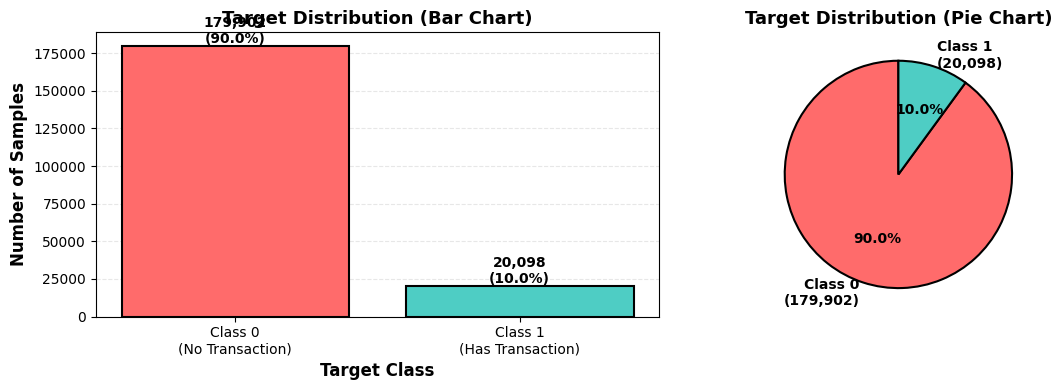

✅ Visualization saved as '01_target_distribution.png'

💡 Interpretation:
  • Class 0 is MAJORITY: 90.0% of samples
  • Class 1 is MINORITY: 10.0% of samples
  • This is an IMBALANCED dataset
  • When training our model, we should prioritize AUC-ROC over accuracy


In [14]:
# ============================================================================
# PHASE 2 - STEP 1: TARGET DISTRIBUTION VISUALIZATION
# ============================================================================

print("\n\n" + "=" * 70)
print("PHASE 2: DATA VISUALIZATION - RELATIONSHIP EXPLORATION")
print("=" * 70)

import matplotlib.pyplot as plt
import seaborn as sns

print("\n📊 STEP 1: Target Distribution Visualization")
print("-" * 70)

# Create a figure with 2 subplots: Bar chart and Pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Bar Chart ---
target_counts = train_df['target'].value_counts().sort_index()
colors_bar = ['#FF6B6B', '#4ECDC4']  # Red for 0, Teal for 1
bars = axes[0].bar(target_counts.index, target_counts.values, color=colors_bar, edgecolor='black', linewidth=1.5)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}\n({height/len(train_df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_xlabel('Target Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].set_title('Target Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Class 0\n(No Transaction)', 'Class 1\n(Has Transaction)'])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_axisbelow(True)

# --- Pie Chart ---
labels = [f'Class 0\n({target_counts[0]:,})', f'Class 1\n({target_counts[1]:,})']
axes[1].pie(target_counts.values, labels=labels, colors=colors_bar, autopct='%1.1f%%',
           startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
axes[1].set_title('Target Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Visualization saved as '01_target_distribution.png'")
print(f"\n💡 Interpretation:")
if target_counts[0] > target_counts[1]:
    print(f"  • Class 0 is MAJORITY: {target_counts[0]/len(train_df)*100:.1f}% of samples")
    print(f"  • Class 1 is MINORITY: {target_counts[1]/len(train_df)*100:.1f}% of samples")
    print(f"  • This is an IMBALANCED dataset")
    print(f"  • When training our model, we should prioritize AUC-ROC over accuracy")



📊 STEP 2: Correlation Analysis - Which Features Relate to Target?
----------------------------------------------------------------------

Top 20 Features Most Correlated with Target:
----------------------------------------------------------------------
Rank  Feature    Correlation     Interpretation                
----------------------------------------------------------------------
1     var_81     -0.080917      ↓ Negative   (Weak)
2     var_139    -0.074080      ↓ Negative   (Weak)
3     var_12     -0.069489      ↓ Negative   (Weak)
4     var_6      +0.066731      ↑ Positive   (Weak)
5     var_110    +0.064275      ↑ Positive   (Weak)
6     var_146    -0.063644      ↓ Negative   (Weak)
7     var_53     +0.063399      ↑ Positive   (Weak)
8     var_26     +0.062422      ↑ Positive   (Weak)
9     var_76     -0.061917      ↓ Negative   (Weak)
10    var_174    -0.061669      ↓ Negative   (Weak)
11    var_22     +0.060558      ↑ Positive   (Weak)
12    var_21     -0.058483      ↓ Neg

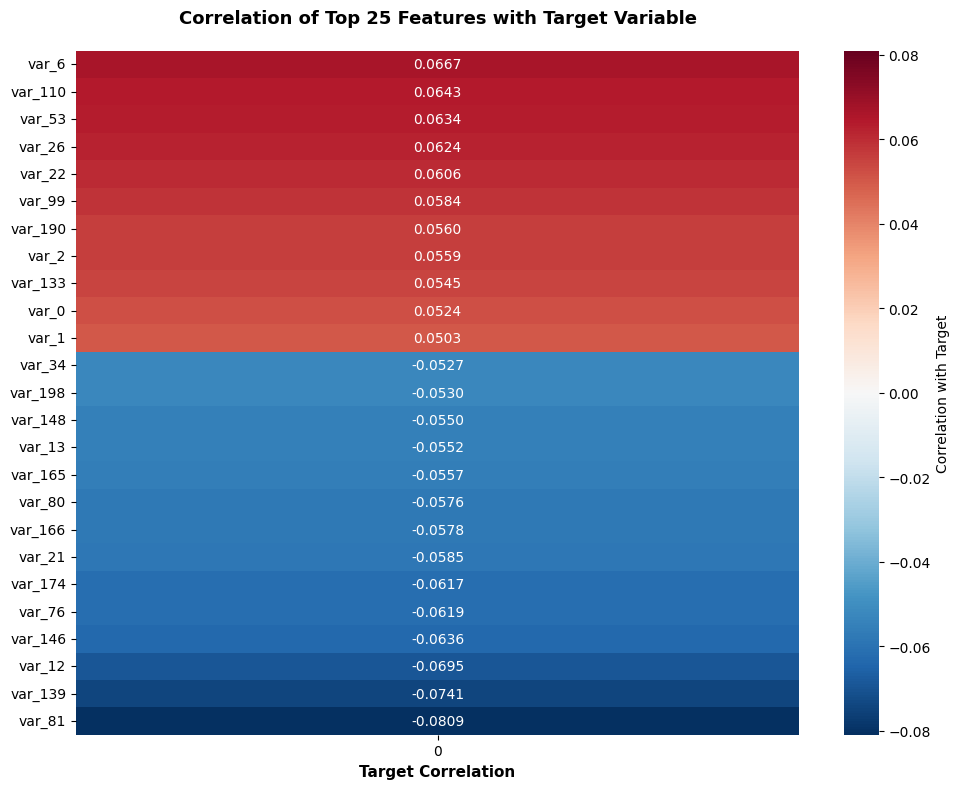


✅ Visualization saved as '02_correlation_with_target.png'

💡 Key Insights:
  • Maximum absolute correlation: 0.080917
  • Most features have WEAK correlation with target (typical for financial data)
  • This means feature engineering will be CRITICAL for model performance
  • We cannot rely on just raw features; we need to create informative combinations


In [15]:
# ============================================================================
# PHASE 2 - STEP 2: CORRELATION ANALYSIS - TARGET RELATIONSHIPS
# ============================================================================

print("\n\n📊 STEP 2: Correlation Analysis - Which Features Relate to Target?")
print("-" * 70)

# Get feature columns
feature_cols = [col for col in train_df.columns if col.startswith('var_')]

# Calculate correlation of each feature with the target
correlations_with_target = train_df[feature_cols + ['target']].corr()['target'].drop('target')

# Sort by absolute correlation (magnitude matters, positive or negative)
correlations_sorted = correlations_with_target.abs().sort_values(ascending=False)

print(f"\nTop 20 Features Most Correlated with Target:")
print("-" * 70)
print(f"{'Rank':<5} {'Feature':<10} {'Correlation':<15} {'Interpretation':<30}")
print("-" * 70)

for i, (feat, abs_corr) in enumerate(correlations_sorted.head(20).items(), 1):
    actual_corr = correlations_with_target[feat]
    direction = "↑ Positive" if actual_corr > 0 else "↓ Negative"
    strength = "Strong" if abs_corr > 0.1 else "Weak" if abs_corr > 0.05 else "Very Weak"
    print(f"{i:<5} {feat:<10} {actual_corr:>+.6f}      {direction:<12} ({strength})")

# --- Visualization: Heatmap of Top 20-30 Correlated Features ---
top_n = 25
top_features = correlations_sorted.head(top_n).index.tolist()

# Create correlation matrix for these top features + target
corr_matrix_subset = train_df[top_features + ['target']].corr()

# Extract only target correlations for cleaner heatmap
target_corr = corr_matrix_subset['target'].drop('target').sort_values(ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap
sns.heatmap(target_corr.values.reshape(-1, 1), 
            yticklabels=target_corr.index,
            cmap='RdBu_r',  # Red-blue colormap (Red=positive, Blue=negative)
            center=0,
            annot=True,  # Show correlation values
            fmt='.4f',
            cbar_kws={'label': 'Correlation with Target'},
            vmin=-max(abs(correlations_with_target)),
            vmax=max(abs(correlations_with_target)),
            ax=ax)

ax.set_title('Correlation of Top 25 Features with Target Variable', 
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Target Correlation', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('02_correlation_with_target.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved as '02_correlation_with_target.png'")
print(f"\n💡 Key Insights:")
print(f"  • Maximum absolute correlation: {correlations_sorted.max():.6f}")
print(f"  • Most features have WEAK correlation with target (typical for financial data)")
print(f"  • This means feature engineering will be CRITICAL for model performance")
print(f"  • We cannot rely on just raw features; we need to create informative combinations")



📊 STEP 3: Feature-Target Relationships - Can We Separate the Classes?
----------------------------------------------------------------------

Creating box plots for top 12 most correlated features...
Features: var_81, var_139, var_12, var_6, var_110, var_146...


C:\Users\itspr\AppData\Local\Temp\ipykernel_6268\3519031386.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot,
C:\Users\itspr\AppData\Local\Temp\ipykernel_6268\3519031386.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot,
C:\Users\itspr\AppData\Local\Temp\ipykernel_6268\3519031386.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot,
C:\Users\itspr\AppData\Local\Temp\ipykernel_6268\3519031386.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matpl

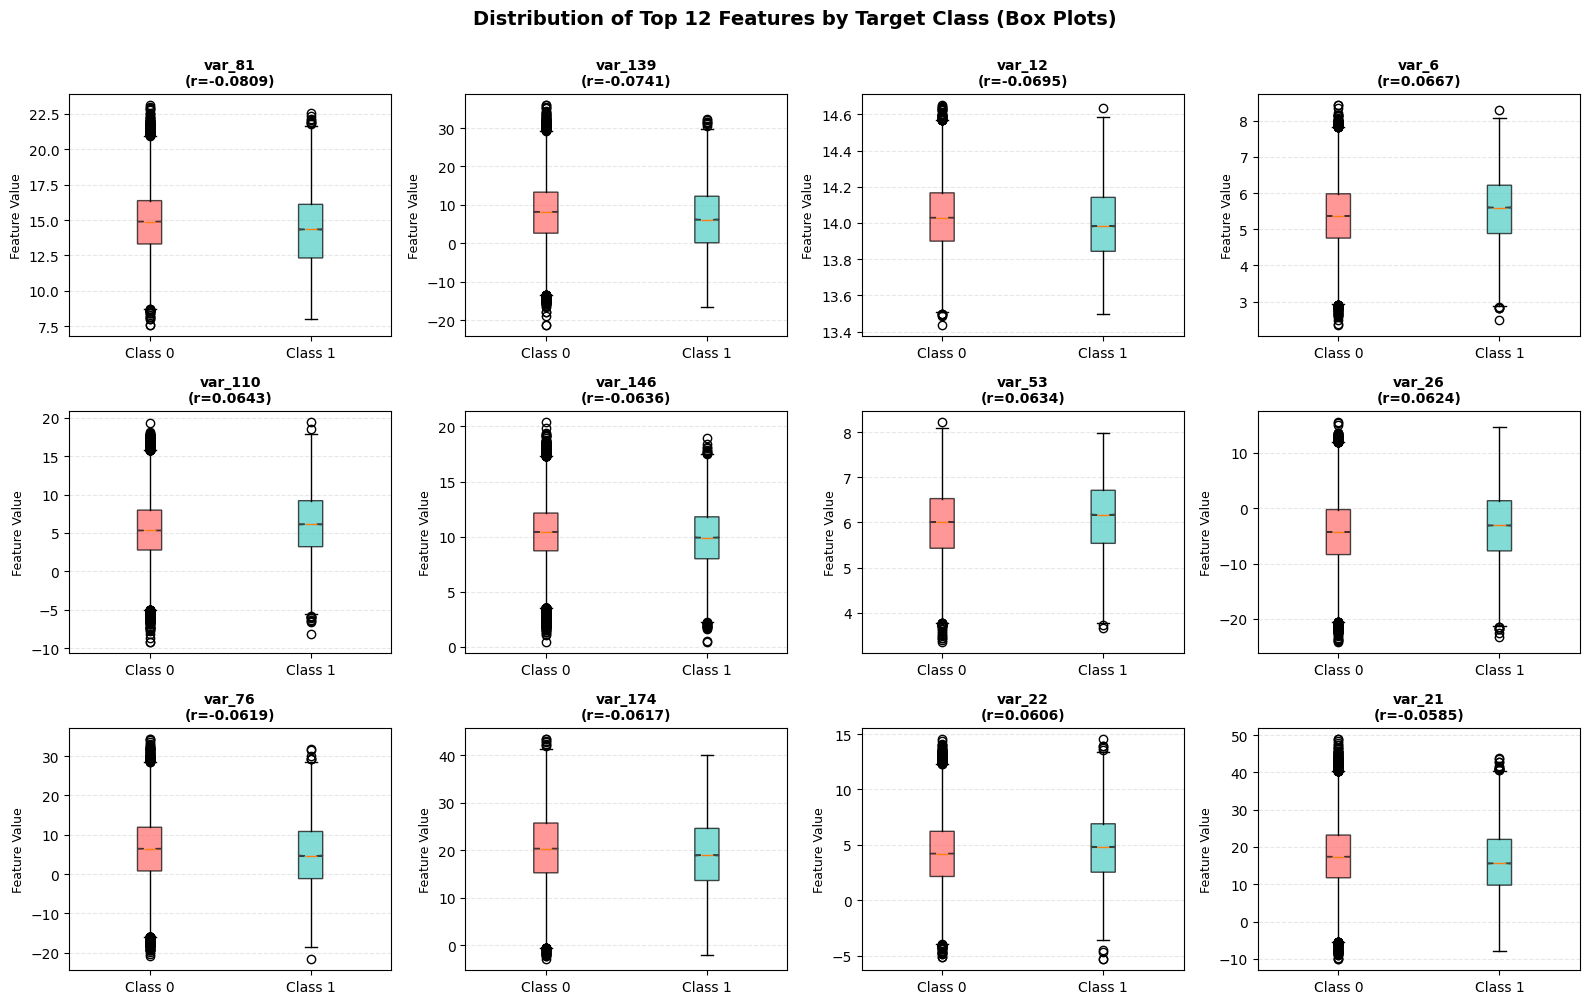

✅ Box plots saved as '03_feature_target_boxplots.png'

💡 What Box Plots Show:
  • LEFT vs RIGHT: Differences between Class 0 and Class 1
  • Middle line: MEDIAN (50th percentile)
  • Box edges: 25th and 75th percentiles (middle 50% of data)
  • Whiskers: Min/Max values
  • Circles: Outliers
  • GOOD sign: Boxes for Class 0 and Class 1 overlap minimally (clear separation)
  • BAD sign: Boxes completely overlap (feature doesn't help distinguish classes)


Creating violin plots for top ['var_81', 'var_139', 'var_12', 'var_6', 'var_110', 'var_146'] features...


C:\Users\itspr\AppData\Local\Temp\ipykernel_6268\3519031386.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Class', y=feature,
C:\Users\itspr\AppData\Local\Temp\ipykernel_6268\3519031386.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Class', y=feature,
C:\Users\itspr\AppData\Local\Temp\ipykernel_6268\3519031386.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Class', y=feature,
C:\Users\itspr\AppData\Local\Temp\ipykernel_6268\3519031386.py:73: FutureWarning: 

P

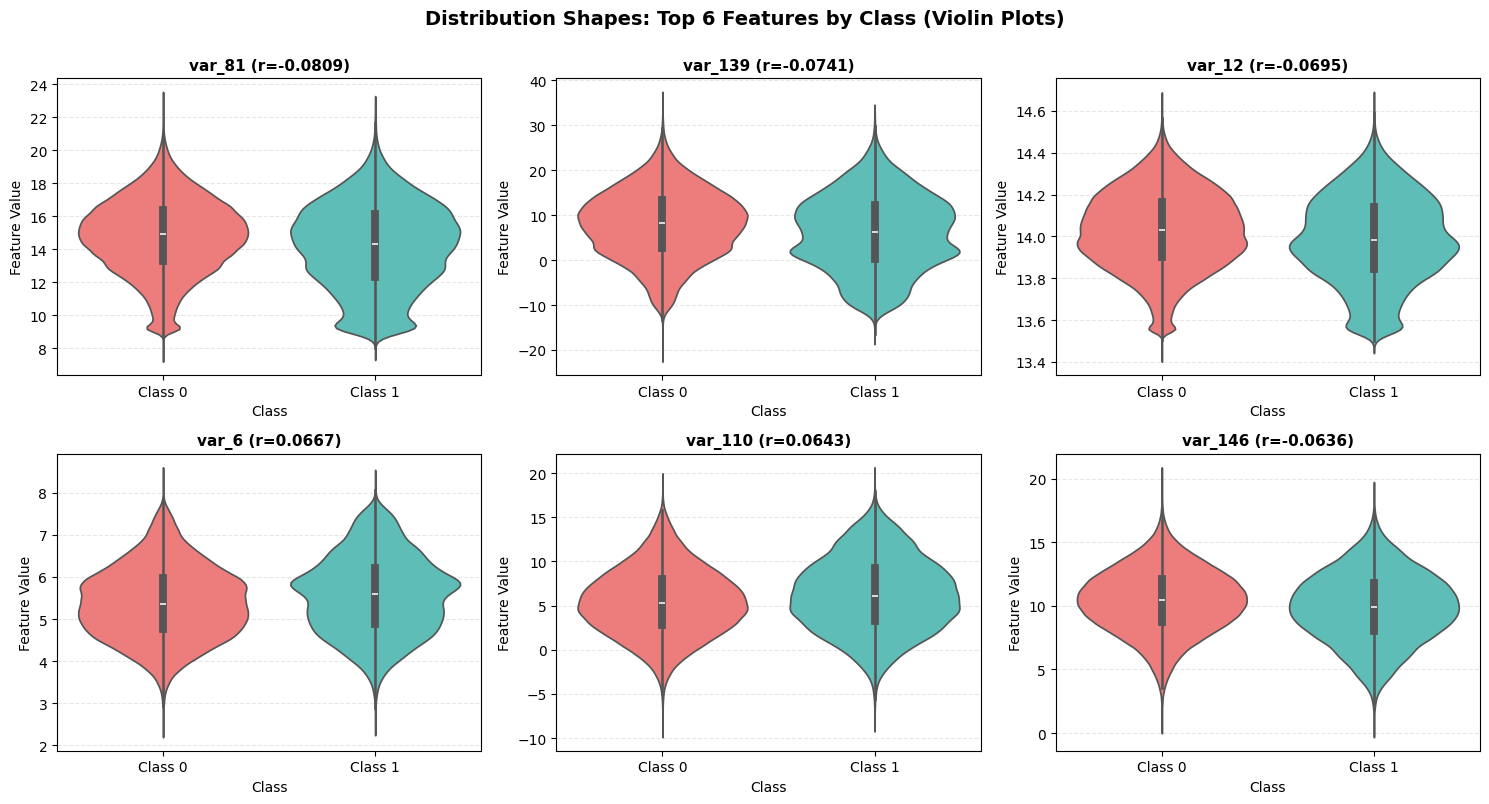

✅ Violin plots saved as '04_feature_target_violin.png'

💡 What Violin Plots Show:
  • Width of shape: How concentrated the data is at that value
  • NARROW neck: Values cluster within a small range
  • WIDE belly: Values spread across a wider range
  • Better than box plots for understanding distribution shape


In [16]:
# ============================================================================
# PHASE 2, STEP 3: FEATURE-TARGET RELATIONSHIPS (Box & Violin Plots)
# ============================================================================

print("\n\n📊 STEP 3: Feature-Target Relationships - Can We Separate the Classes?")
print("-" * 70)

# Get top 12 most correlated features for visualization
top_n_features = 12
top_features = correlations_sorted.head(top_n_features).index.tolist()

print(f"\nCreating box plots for top {top_n_features} most correlated features...")
print(f"Features: {', '.join(top_features[:6])}...")

# --- Box Plots: Compare distributions of feature values between target=0 and target=1 ---
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

for idx, feature in enumerate(top_features):
    # Box plot
    data_to_plot = [train_df[train_df['target'] == 0][feature],
                    train_df[train_df['target'] == 1][feature]]
    
    bp = axes[idx].boxplot(data_to_plot, 
                           labels=['Class 0', 'Class 1'],
                           patch_artist=True,
                           notch=True)  # Notches help compare medians
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Styling
    axes[idx].set_title(f'{feature}\n(r={correlations_with_target[feature]:.4f})', 
                       fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Feature Value', fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].set_axisbelow(True)

# Remove extra subplots if odd number of features
for idx in range(len(top_features), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribution of Top 12 Features by Target Class (Box Plots)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('03_feature_target_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Box plots saved as '03_feature_target_boxplots.png'")
print(f"\n💡 What Box Plots Show:")
print(f"  • LEFT vs RIGHT: Differences between Class 0 and Class 1")
print(f"  • Middle line: MEDIAN (50th percentile)")
print(f"  • Box edges: 25th and 75th percentiles (middle 50% of data)")
print(f"  • Whiskers: Min/Max values")
print(f"  • Circles: Outliers")
print(f"  • GOOD sign: Boxes for Class 0 and Class 1 overlap minimally (clear separation)")
print(f"  • BAD sign: Boxes completely overlap (feature doesn't help distinguish classes)")

# --- Violin Plots: Show full distribution shape ---
print(f"\n\nCreating violin plots for top {top_features[:6]} features...")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(top_features[:6]):
    # Prepare data in long format for seaborn
    plot_data = train_df[[feature, 'target']].copy()
    plot_data['Class'] = plot_data['target'].apply(lambda x: f'Class {int(x)}')
    
    # Violin plot
    sns.violinplot(data=plot_data, x='Class', y=feature, 
                   palette=['#FF6B6B', '#4ECDC4'],
                   ax=axes[idx])
    
    axes[idx].set_title(f'{feature} (r={correlations_with_target[feature]:.4f})', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Feature Value', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].set_axisbelow(True)

plt.suptitle('Distribution Shapes: Top 6 Features by Class (Violin Plots)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('04_feature_target_violin.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Violin plots saved as '04_feature_target_violin.png'")
print(f"\n💡 What Violin Plots Show:")
print(f"  • Width of shape: How concentrated the data is at that value")
print(f"  • NARROW neck: Values cluster within a small range")
print(f"  • WIDE belly: Values spread across a wider range")
print(f"  • Better than box plots for understanding distribution shape")



📊 STEP 4: Feature-Feature Correlations - Identifying Redundant Features
----------------------------------------------------------------------

Analyzing correlations among top 50 most important features...


Finding Feature Pairs with High Redundancy (|correlation| > 0.90):
----------------------------------------------------------------------
✅ No highly correlated feature pairs found!
   → Features are reasonably independent


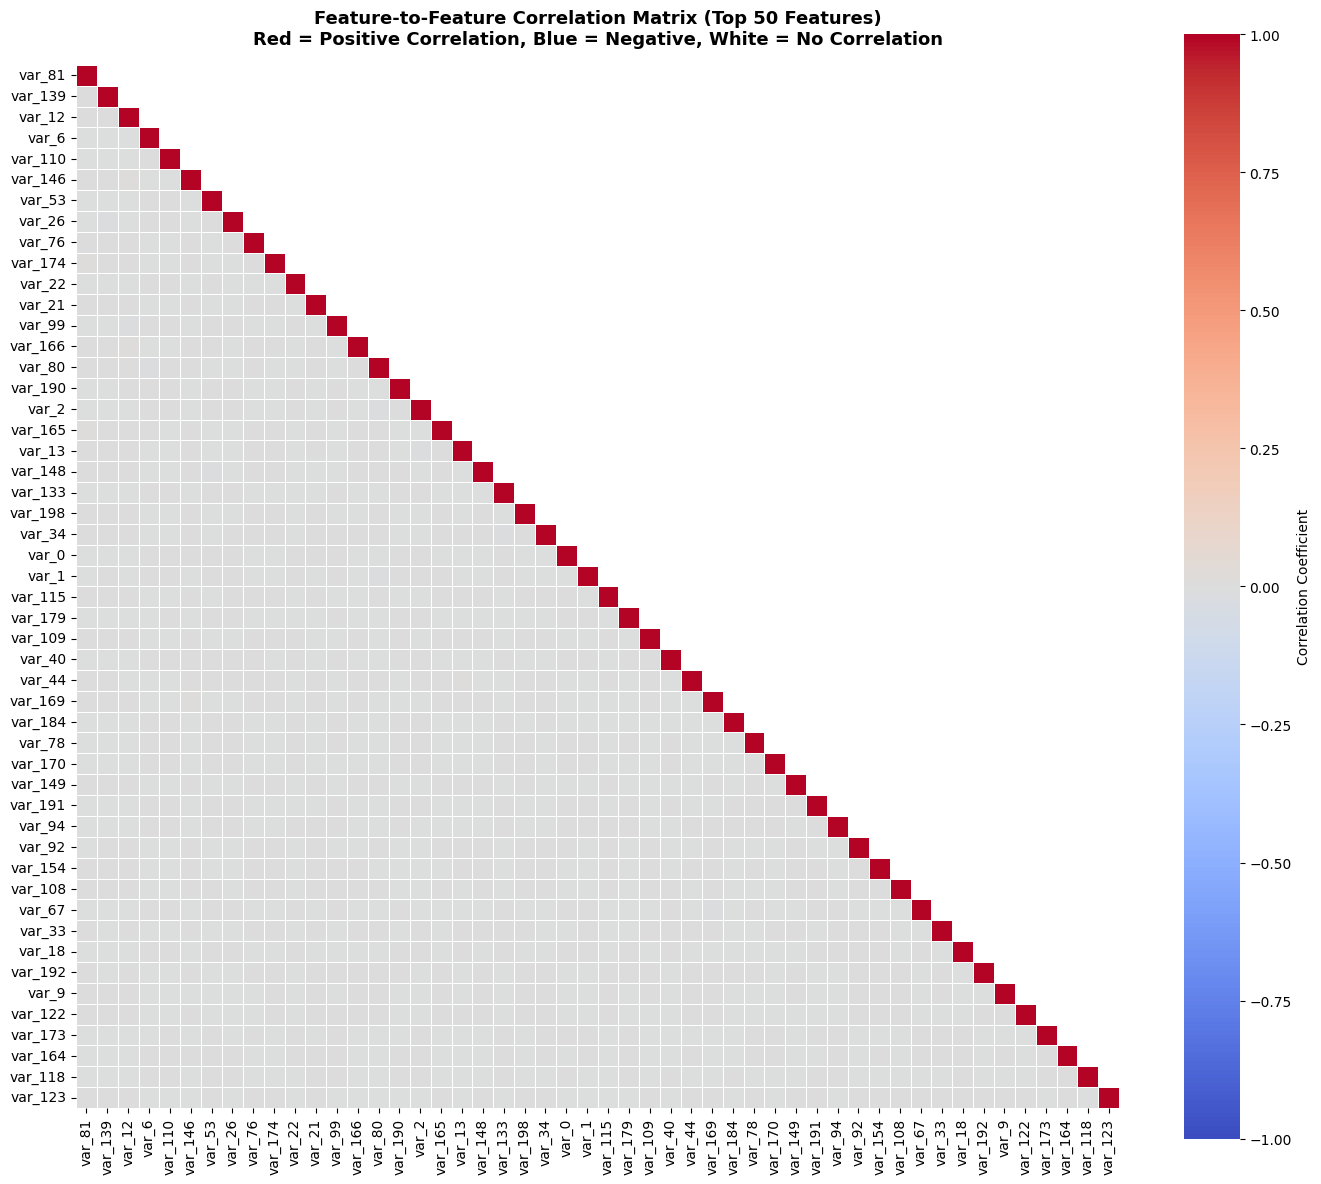


✅ Heatmap saved as '05_feature_feature_correlation.png'

💡 Key Insights from Feature Correlations:
  • Dark (white/light) squares: Features are INDEPENDENT (good!)
  • Bright red squares: Features are highly POSITIVELY correlated (redundant)
  • Bright blue squares: Features are highly NEGATIVELY correlated (inverse)
  • Most financial features naturally have low inter-correlation
  • This means we can keep most features without redundancy penalty

✅ PHASE 2 COMPLETE: Data Visualization & Relationship Exploration


In [ ]:
# ============================================================================
# PHASE 2, STEP 4: FEATURE-FEATURE CORRELATIONS (Redundancy Detection)
# ============================================================================

print("\n\n📊 STEP 4: Feature-Feature Correlations - Identifying Redundant Features")
print("-" * 70)

# Get top 50 most correlated features with target (these are the "useful" ones)
top_50_features = correlations_sorted.head(50).index.tolist()

# Calculate correlation matrix
corr_matrix_50 = train_df[top_50_features].corr()

print(f"\nAnalyzing correlations among top 50 most important features...")

# Find highly correlated pairs (absolute correlation > 0.9)
print(f"\n\nFinding Feature Pairs with High Redundancy (|correlation| > 0.90):")
print("-" * 70)

highly_correlated_pairs = []
for i in range(len(corr_matrix_50.columns)):
    for j in range(i+1, len(corr_matrix_50.columns)):
        corr_value = corr_matrix_50.iloc[i, j]
        if abs(corr_value) > 0.90:
            feat1 = corr_matrix_50.columns[i]
            feat2 = corr_matrix_50.columns[j]
            highly_correlated_pairs.append((feat1, feat2, corr_value))

if len(highly_correlated_pairs) == 0:
    print("✅ No highly correlated feature pairs found!")
    print("   → Features are reasonably independent")
else:
    print(f"Found {len(highly_correlated_pairs)} highly correlated pairs:\n")
    for i, (feat1, feat2, corr) in enumerate(sorted(highly_correlated_pairs, 
                                                      key=lambda x: abs(x[2]), 
                                                      reverse=True)[:10], 1):
        print(f"  {i}. {feat1} <-> {feat2}: correlation = {corr:.6f}")
        print(f"     (These 2 features contain nearly identical information)")

# --- Heatmap of Top 50 Features ---
fig, ax = plt.subplots(figsize=(14, 12))

# Mask for upper triangle (to avoid redundancy in visualization)
mask = np.triu(np.ones_like(corr_matrix_50, dtype=bool), k=1)

# Create heatmap
sns.heatmap(corr_matrix_50, 
            mask=mask,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'},
            vmin=-1, vmax=1,
            ax=ax)

ax.set_title('Feature-to-Feature Correlation Matrix (Top 50 Features)\n' + 
             'Red = Positive Correlation, Blue = Negative, White = No Correlation',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('05_feature_feature_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ Heatmap saved as '05_feature_feature_correlation.png'")
print(f"\n💡 Key Insights from Feature Correlations:")
print(f"  • Dark (white/light) squares: Features are INDEPENDENT (good!)")
print(f"  • Bright red squares: Features are highly POSITIVELY correlated (redundant)")
print(f"  • Bright blue squares: Features are highly NEGATIVELY correlated (inverse)")
print(f"  • Most financial features naturally have low inter-correlation")
print(f"  • This means we can keep most features without redundancy penalty")

print("\n" + "=" * 70)
print("✅ PHASE 2 COMPLETE: Data Visualization & Relationship Exploration")
print("=" * 70)

In [27]:
# Import additional libraries for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
import pandas as pd

# --- 1. Prepare the Data ---
# The competition asks to predict the 'target' variable.
# We'll use all 'var_' columns as features.
# 'ID_code' is just an identifier and should not be used for training.

print("Preparing data for training...")

# Separate features (X) and the target variable (y)
X = train_df.drop(['ID_code', 'target'], axis=1)
y = train_df['target']

# The test set for final predictions
X_test = test_df.drop('ID_code', axis=1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("-" * 30)


# --- 2. Split Data into Training and Validation Sets ---
# We split our data to train the model on one part (training set)
# and evaluate its performance on another part it hasn't seen (validation set).
# 'stratify=y' ensures that both sets have a similar proportion of target values,
# which is important for imbalanced datasets.

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,       # Using 20% of the data for validation
    random_state=42,     # for reproducibility
    stratify=y           # Recommended for classification
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print("-" * 30)


# --- 3. Train a LightGBM Model ---
# We'll use a LightGBM Classifier. The parameters chosen are a good starting point.
# 'objective':'binary' tells the model we are doing binary classification.
# 'metric':'auc' is the evaluation metric for the competition.

print("Training the LightGBM model...")

lgbm = LGBMClassifier(
    objective='binary',
    metric='auc',
    n_estimators=1000,         # Number of boosting rounds
    learning_rate=0.01,
    num_leaves=35,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,                 # Use all available CPU cores
    colsample_bytree=0.7,
    subsample=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    early_stopping = 100,
    verbose=100
)

# We use early stopping to find the optimal number of estimators
# and prevent overfitting. It will stop training if the validation score
# doesn't improve for 100 consecutive rounds.
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc'
)

print("-" * 30)


# --- 4. Evaluate the Model ---
# Predict probabilities on the validation set. We need the probability of the positive class (1).
val_predictions = lgbm.predict_proba(X_val)[:, 1]

# This line calculates your custom metric.
# It assumes 'y_val' and 'val_predictions' are available from the model training and evaluation steps.

custom_metric = (abs((y_val == 0).sum() - (val_predictions <= 0.5).sum()) + abs(y_val.sum() - (val_predictions > 0.5).sum())) / len(y_val)

print(f"Custom Class Count Metric: {custom_metric}")


# Calculate the ROC AUC score.
auc = roc_auc_score(y_val, val_predictions)
print(f"Validation ROC AUC Score: {auc:.5f}")
print("-" * 30)


# --- 5. Create Submission File ---
# Now, we use the trained model to make predictions on the actual test data.
print("Making predictions on the test set...")
test_predictions = lgbm.predict_proba(X_test)[:, 1]

# Create the submission DataFrame in the format required by the competition.
submission_df = pd.DataFrame({'ID_code': test_df['ID_code'], 'target': test_predictions})

# Save the submission file.
submission_df.to_csv('submission.csv', index=False)

print("\nSubmission file 'submission.csv' has been created successfully!")
print("Top 5 rows of the submission file:")
print(submission_df.head())

Preparing data for training...
Features shape: (200000, 200)
Target shape: (200000,)
------------------------------
Training set size: 160000
Validation set size: 40000
------------------------------
Training the LightGBM model...
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] Number of positive: 16078, number of negative: 143922
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.000004
[LightGBM] [Debug] init for col-wise cost 0.000029 seconds, init for row-wise cost 0.224704 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.430624 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 200
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping=100 will be ignored. Current 